# 03 — Modelagem Baseline

**Objetivo:** Comparar múltiplos modelos com validação cruzada estratificada e selecionar o melhor candidato para tuning.

**Inputs:** `data/processed/X_treino.parquet`, `data/processed/y_treino.parquet`, `models/pipeline.pkl`

**Outputs:** `reports/comparativo_modelos.csv`, `reports/figures/*.png`

---

**Roteiro:**

1. Setup — imports
2. Carregamento de Dados e Artefatos
3. Cross-Validation com ImbPipeline
4. Visualização - Visualização Comparativa entre modelos
5. Fechamento


In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    make_scorer,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from src.config import CAMINHOS, CONFIG
from src.viz_config import CORES, PALETTE


warnings.filterwarnings("ignore")


SEED = CONFIG["dados"]["random_state"]
TARGET = CONFIG["dados"]["target_col"]

PROC_DIR = CAMINHOS.dados_processed
MODEL_DIR = CAMINHOS.modelos
FIG_DIR = CAMINHOS.figures

REPORTS = CAMINHOS.reports
REPORTS.mkdir(parents=True, exist_ok=True)


print("✅ Setup OK")
print(f"   TARGET  : {TARGET}")
print(f"   SEED    : {SEED}")

✅ Setup OK
   TARGET  : Attrition
   SEED    : 42


### Etapa 2 - Carregamento de Dados e Artefatos

Nesta etapa, foram carregados:

- os conjuntos de treino e teste;
- os preprocessors desenvolvidos anteriormente;
- as pipelines específicas para modelos lineares e algoritmos tree-based.

Após o carregamento, os objetos ColumnTransformer foram extraídos das pipelines.

In [2]:
X_train_raw = pd.read_parquet(PROC_DIR / 'X_treino_raw.parquet')
X_test_raw  = pd.read_parquet(PROC_DIR / 'X_teste_raw.parquet')
y_train     = pd.read_parquet(PROC_DIR / 'y_treino.parquet').squeeze()
y_test      = pd.read_parquet(PROC_DIR / 'y_teste.parquet').squeeze()

print(f'X_train_raw : {X_train_raw.shape}')
print(f'X_test_raw  : {X_test_raw.shape}')
print(f'Taxa Attrition treino : {y_train.mean():.3f}')
print(f'Taxa Attrition teste  : {y_test.mean():.3f}')

X_train_raw : (1176, 30)
X_test_raw  : (294, 30)
Taxa Attrition treino : 0.162
Taxa Attrition teste  : 0.160


In [3]:
pipeline_linear = joblib.load(MODEL_DIR / 'pipeline_linear.pkl')
pipeline_arvore = joblib.load(MODEL_DIR / 'pipeline_arvore.pkl')

pre_linear = pipeline_linear.named_steps['preprocessor']
pre_arvore = pipeline_arvore.named_steps['preprocessor']

print(f'   pipeline_linear : com StandardScaler')
print(f'   pipeline_arvore : sem StandardScaler')

   pipeline_linear : com StandardScaler
   pipeline_arvore : sem StandardScaler


Nesta etapa, foram definidos os scorers utilizados na avaliação dos modelos, permitindo medir o desempenho sob diferentes métricas relevantes para o problema de classificação desbalanceada. O uso do `StratifiedKFold` garante que a proporção entre as classes seja preservada em cada fold e o `RandomUnderSampler` para reduzir o desbalanceamento entre as classes durante o treinamento, equilibrando a quantidade de exemplos da classe majoritária e minoritária.

Em seguida, foi configurada a estratégia de validação cruzada utilizando:

- `StratifiedKFold`
- `RandomUnderSampler (RUS)`

A validação cruzada foi instanciada da seguinte forma:

- `n_splits = 5`
- `shuffle = True`
- `random_state = SEED`

In [4]:
SCORERS = {
    'pr_auc':  make_scorer(average_precision_score, response_method='predict_proba', pos_label=1),
    'roc_auc': make_scorer(roc_auc_score, response_method='predict_proba'),
    'recall':  'recall',
    'f1': make_scorer(f1_score, zero_division=0),
}

CV  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
RUS = RandomUnderSampler(random_state=SEED)

Vamos agora criar um dicionário com os classificadores que serão utilizados.

In [5]:
CLASSIFICADORES = {
    'Dummy': {
        'preprocessor': None,
        'classificador': DummyClassifier(strategy='stratified', random_state=SEED),
    },
    'LogisticRegression': {
        'preprocessor': pre_linear,
        'classificador': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    },
    'DecisionTree': {
        'preprocessor': pre_arvore,
        'classificador': DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
    },
    'LGBMClassifier': {
        'preprocessor': pre_arvore,
        'classificador': LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1),
    },
    'XGBClassifier': {
        'preprocessor': pre_arvore,
        'classificador': XGBClassifier(random_state=SEED, n_jobs=-1, verbosity=0),
    },
    'SVC': {
        'preprocessor': pre_linear,
        'classificador': SVC(probability=True, class_weight='balanced', random_state=SEED),
    },
    'KNN': {
        'preprocessor': pre_linear,
        'classificador': KNeighborsClassifier(n_jobs=-1),
    },
}

print(f'\nModelos definidos : {list(CLASSIFICADORES.keys())}')
print('✅ Definição OK')


Modelos definidos : ['Dummy', 'LogisticRegression', 'DecisionTree', 'LGBMClassifier', 'XGBClassifier', 'SVC', 'KNN']
✅ Definição OK


### Etapa 3 - Cross-Validation com ImbPipeline

In [6]:
print('⏳ Avaliando modelos...\n')
resultados = []
pipelines  = {}

for nome, config in CLASSIFICADORES.items():
    pre   = config['preprocessor']
    modelo= config['classificador']

    # Montar ImbPipeline
    if pre is None:
        # Dummy — sem preprocessador
        pipe = ImbPipeline([
            ('sampler',     RUS),
            ('classifier',  modelo),
        ])
    else:
        pipe = ImbPipeline([
            ('preprocessor', pre),
            ('sampler',       RUS),
            ('classifier',    modelo),
        ])

    cv = cross_validate(
        pipe, X_train_raw, y_train,
        cv=CV, scoring=SCORERS, n_jobs=-1,
    )

    resultados.append({
        'Modelo':   nome,
        'PR-AUC':   cv['test_pr_auc'].mean(),
        'PR-AUC±':  cv['test_pr_auc'].std(),
        'ROC-AUC':  cv['test_roc_auc'].mean(),
        'Recall':   cv['test_recall'].mean(),
        'F1':       cv['test_f1'].mean(),
    })
    pipelines[nome] = pipe

    print(f'   ✅ {nome:<22} '
          f'PR-AUC: {cv["test_pr_auc"].mean():.4f} '
          f'± {cv["test_pr_auc"].std():.4f} | '
          f'ROC-AUC: {cv["test_roc_auc"].mean():.4f} | '
          f'Recall: {cv["test_recall"].mean():.4f}')

df_res = (pd.DataFrame(resultados)
            .sort_values('PR-AUC', ascending=False)
            .reset_index(drop=True))

print(f'\n=== Comparativo Baseline ===')
display(df_res.style
        .highlight_max(subset=['PR-AUC','ROC-AUC','Recall','F1'],
                       color='#1f4d25')
        .format({'PR-AUC':'{:.4f}','PR-AUC±':'{:.4f}',
                 'ROC-AUC':'{:.4f}','Recall':'{:.4f}',
                 'F1':'{:.4f}'}))

melhor = df_res.iloc[0]['Modelo']
print(f'\n→ Modelo selecionado para NB04: {melhor}')

⏳ Avaliando modelos...

   ✅ Dummy                  PR-AUC: 0.1682 ± 0.0140 | ROC-AUC: 0.5178 | Recall: 0.5316
   ✅ LogisticRegression     PR-AUC: 0.6090 ± 0.0723 | ROC-AUC: 0.8296 | Recall: 0.7684
   ✅ DecisionTree           PR-AUC: 0.2123 ± 0.0328 | ROC-AUC: 0.6170 | Recall: 0.6316
   ✅ LGBMClassifier         PR-AUC: 0.5160 ± 0.0784 | ROC-AUC: 0.7763 | Recall: 0.6474
   ✅ XGBClassifier          PR-AUC: 0.4815 ± 0.0895 | ROC-AUC: 0.7670 | Recall: 0.6684
   ✅ SVC                    PR-AUC: 0.5692 ± 0.0748 | ROC-AUC: 0.8122 | Recall: 0.6842
   ✅ KNN                    PR-AUC: 0.3170 ± 0.0608 | ROC-AUC: 0.6969 | Recall: 0.5737

=== Comparativo Baseline ===


,Modelo,PR-AUC,PR-AUC±,ROC-AUC,Recall,F1
0,LogisticRegression,0.6090,0.0723,0.8296,0.7684,0.5001
1,SVC,0.5692,0.0748,0.8122,0.6842,0.4828
2,LGBMClassifier,0.5160,0.0784,0.7763,0.6474,0.4175
3,XGBClassifier,0.4815,0.0895,0.7670,0.6684,0.4291
4,KNN,0.3170,0.0608,0.6969,0.5737,0.3829
5,DecisionTree,0.2123,0.0328,0.6170,0.6316,0.3434
6,Dummy,0.1682,0.0140,0.5178,0.5316,0.2590



→ Modelo selecionado para NB04: LogisticRegression


### Etapa 4 — Visualização

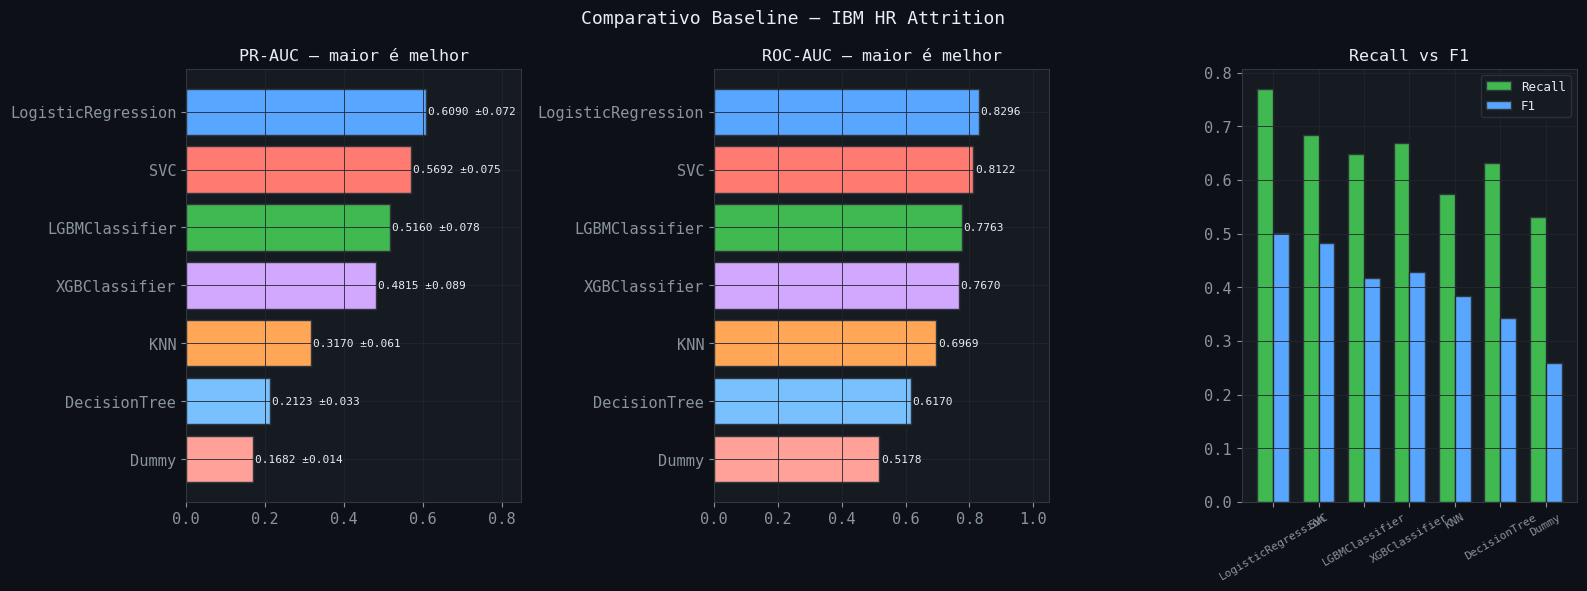

✅ comparativo_modelos.csv salvo


In [7]:
## 4. Visualização Comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

cores = [PALETTE[i % len(PALETTE)] for i in range(len(df_res))]

# PR-AUC
bars = axes[0].barh(df_res['Modelo'], df_res['PR-AUC'],
                    color=cores, edgecolor='#30363d')
axes[0].set_title('PR-AUC — maior é melhor',
                  color=CORES['texto'])
axes[0].set_xlim(0, 0.85)
axes[0].invert_yaxis()
for bar, val, std in zip(bars, df_res['PR-AUC'],
                          df_res['PR-AUC±']):
    axes[0].text(val + 0.005,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.4f} ±{std:.3f}',
                 va='center', fontsize=8,
                 color=CORES['texto'])

# ROC-AUC
bars = axes[1].barh(df_res['Modelo'], df_res['ROC-AUC'],
                    color=cores, edgecolor='#30363d')
axes[1].set_title('ROC-AUC — maior é melhor',
                  color=CORES['texto'])
axes[1].set_xlim(0, 1.05)
axes[1].invert_yaxis()
for bar, val in zip(bars, df_res['ROC-AUC']):
    axes[1].text(val + 0.005,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}',
                 va='center', fontsize=8,
                 color=CORES['texto'])

# Recall vs F1
x     = np.arange(len(df_res))
width = 0.35
axes[2].bar(x - width/2, df_res['Recall'], width,
            label='Recall', color=PALETTE[2],
            edgecolor='#30363d')
axes[2].bar(x + width/2, df_res['F1'], width,
            label='F1', color=PALETTE[0],
            edgecolor='#30363d')
axes[2].set_xticks(x)
axes[2].set_xticklabels(df_res['Modelo'],
                         rotation=30, fontsize=8)
axes[2].set_title('Recall vs F1', color=CORES['texto'])
axes[2].legend(fontsize=9)

plt.suptitle('Comparativo Baseline — IBM HR Attrition',
             color=CORES['texto'], fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb03_comparativo.png',
            dpi=150, bbox_inches='tight')
plt.show()

df_res.to_csv(REPORTS / 'comparativo_modelos.csv', index=False)
print('✅ comparativo_modelos.csv salvo')

### Etapa 5 - Fechamento

In [8]:
figuras = list(FIG_DIR.glob('nb03_*.png'))
print('✅ NB03 — Modelagem Baseline finalizado.')
print(f'\nFiguras: {[f.name for f in sorted(figuras)]}')

✅ NB03 — Modelagem Baseline finalizado.

Figuras: ['nb03_comparativo.png', 'nb03_comparativo_modelos.png']


#### Modelo selecionado

| Métrica | Valor |
|---|---:|
| Modelo | `LogisticRegression` |
| PR-AUC (CV) | `0.6090` |
| ROC-AUC (CV) | `0.8296` |
| Recall (CV) | `0.7684` |

##### Próximo passo

- Tuning de hiperparâmetros com **Optuna**
- Pipeline completo utilizando **ImbPipeline**
- Otimização focada em **PR-AUC**, mantendo alto **Recall** para identificação de casos de attrition

### Resumo

| Etapa | Entregável |
|---|---|
| 1 | Setup — imports, CONFIG, CAMINHOS |
| 2 | Carregamento + Validação cruzada + Scorers + Classificadores` |
| 3 | ross-Validation com ImbPipeline |
| 4 | Gráfico comparativo — 7 modelos lado a lado |
| 5 | CSV salvo + decisão documentada → Log. Reg. para NB04 |